In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    ConfusionMatrixDisplay, f1_score, recall_score,
)
from sklearn.model_selection import (
    GridSearchCV, ParameterGrid, PredefinedSplit,
    StratifiedKFold, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# data load and EDA

In [51]:
data = pd.read_csv("online_shoppers.csv")
data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,S-100000,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,S-100001,0,0.0,0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,S-100002,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,S-100003,0,0.0,0,NaN,2.0,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,S-100004,0,0.0,0,NaN,10.0,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,NaN,True,False


In [52]:
columns = data.select_dtypes(include="number").columns

columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='str')

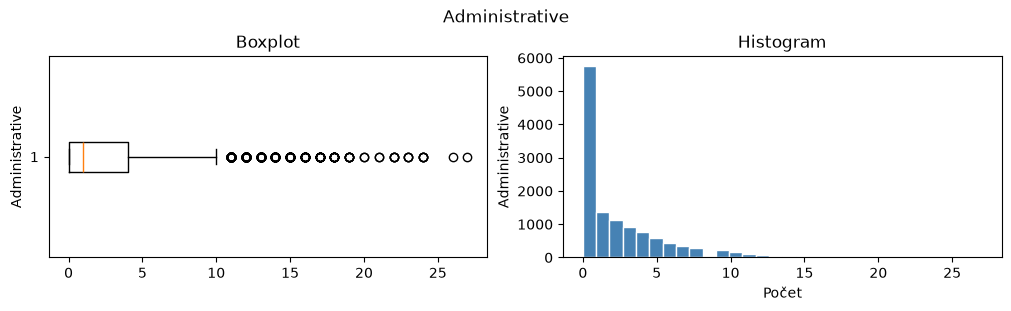

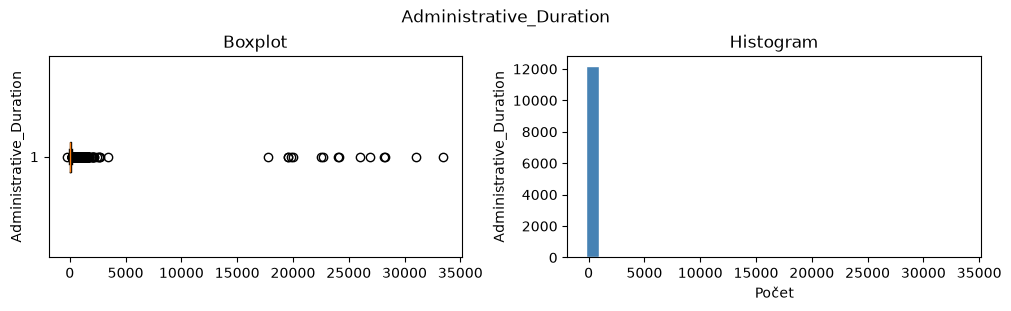

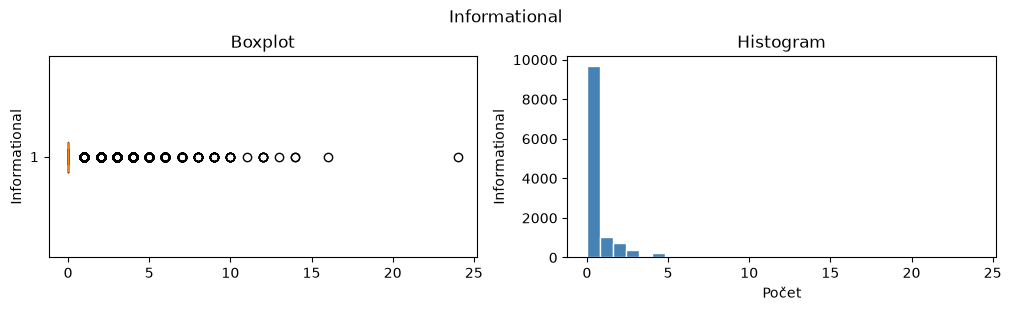

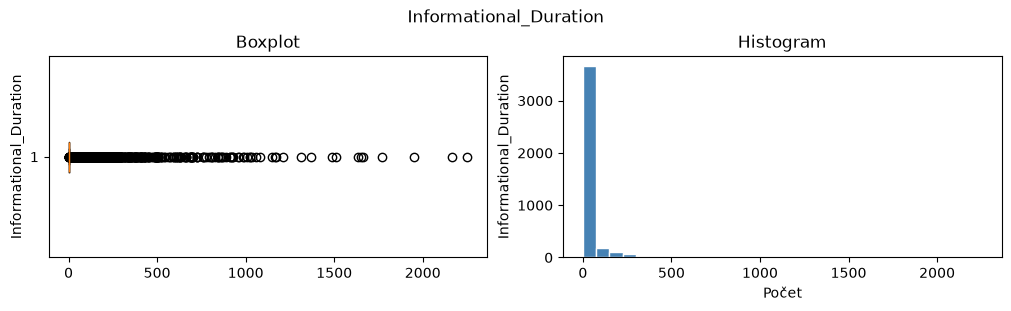

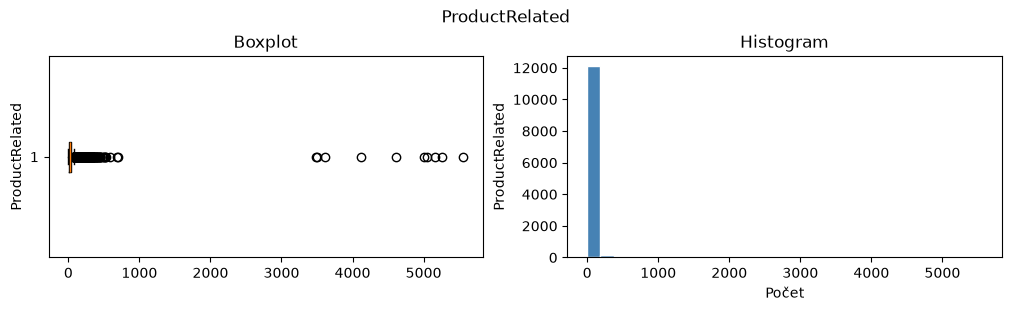

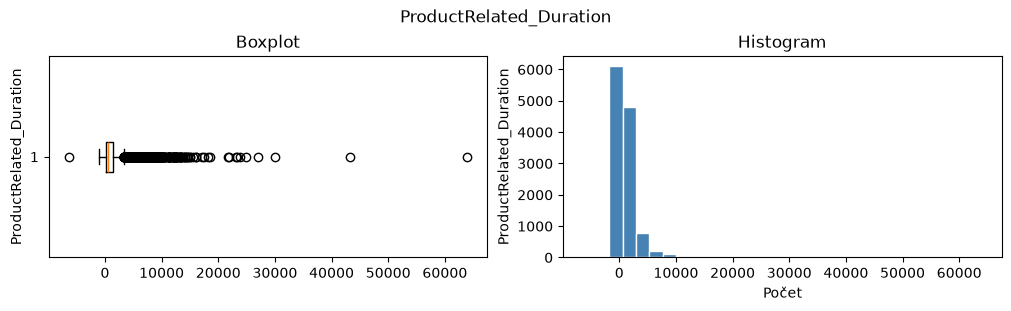

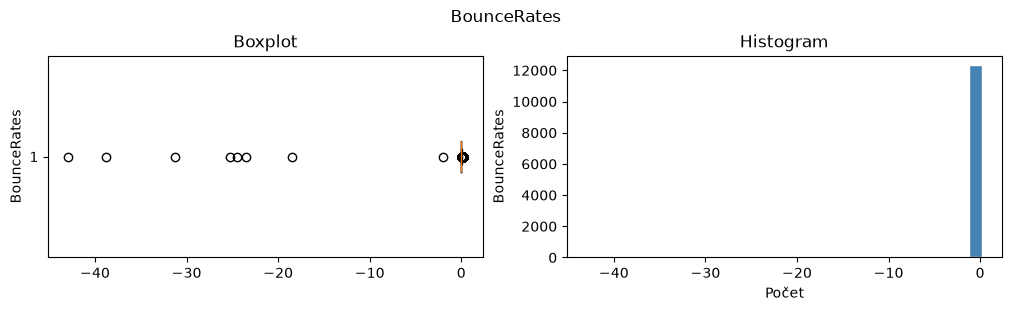

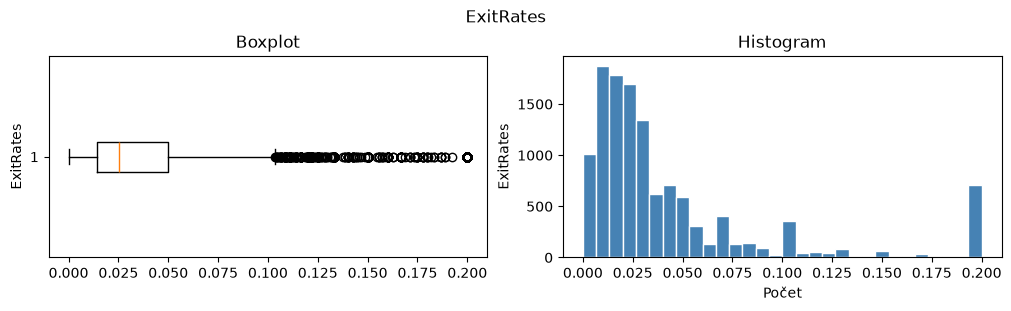

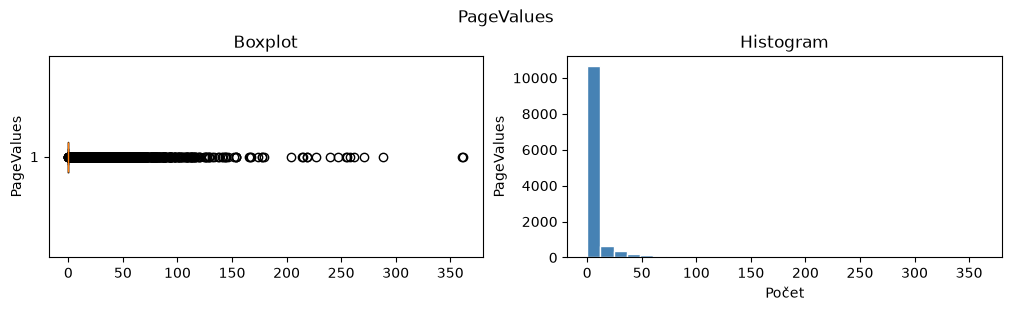

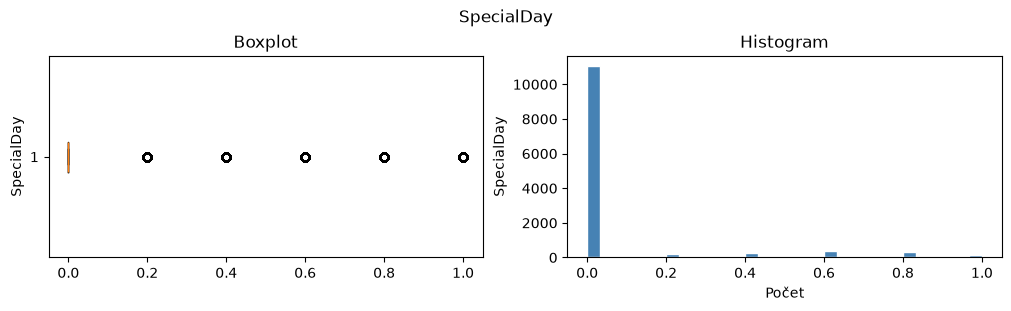

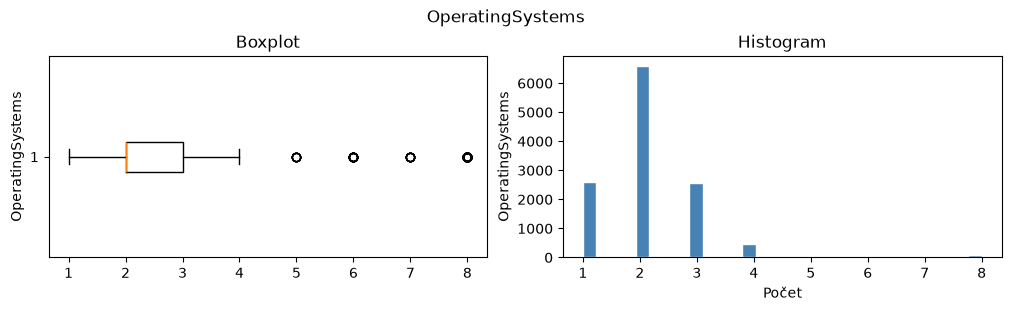

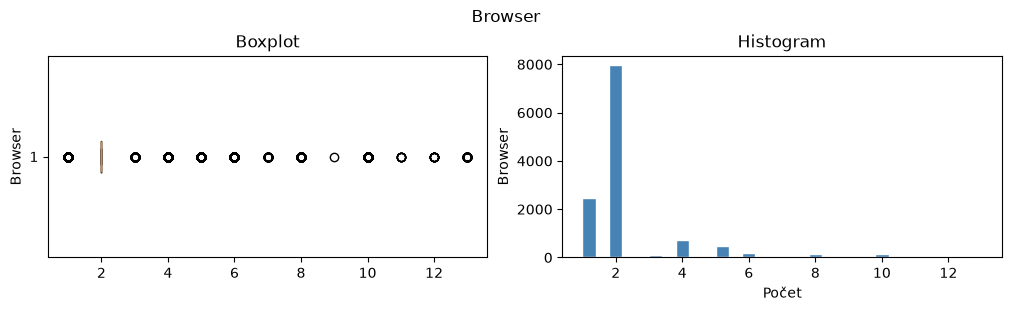

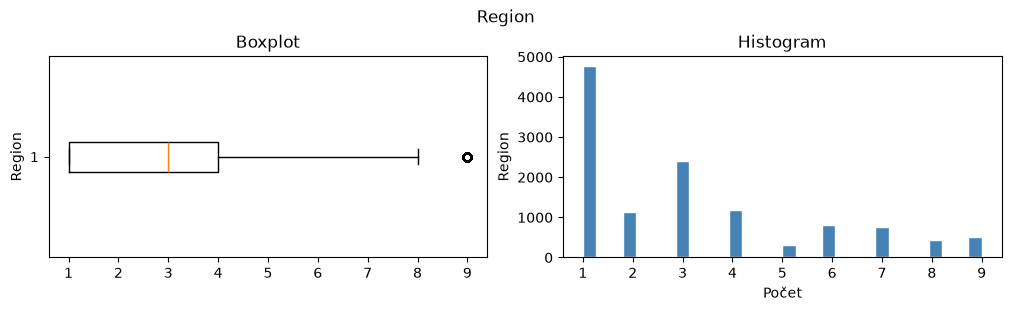

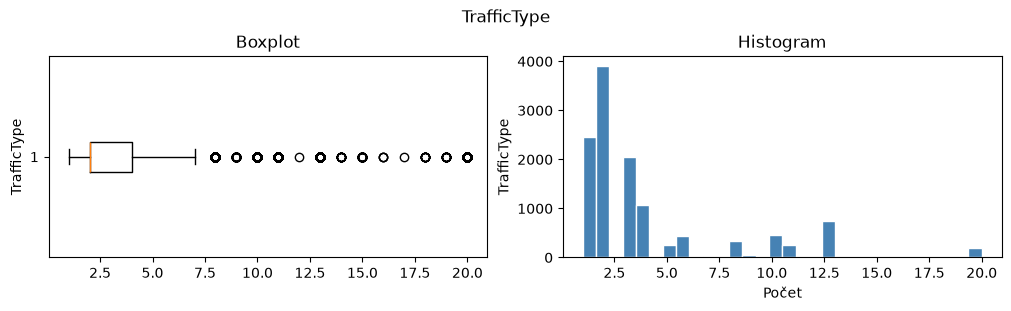

In [53]:
for column in columns:
    values = data[column].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
    axes[0].boxplot(values, orientation="horizontal")
    axes[0].set(title="Boxplot", ylabel=column)
    axes[1].hist(values, bins=30, color="steelblue", edgecolor="white")
    axes[1].set(title="Histogram", xlabel="Počet", ylabel=column)
    fig.suptitle(column)
    plt.show()

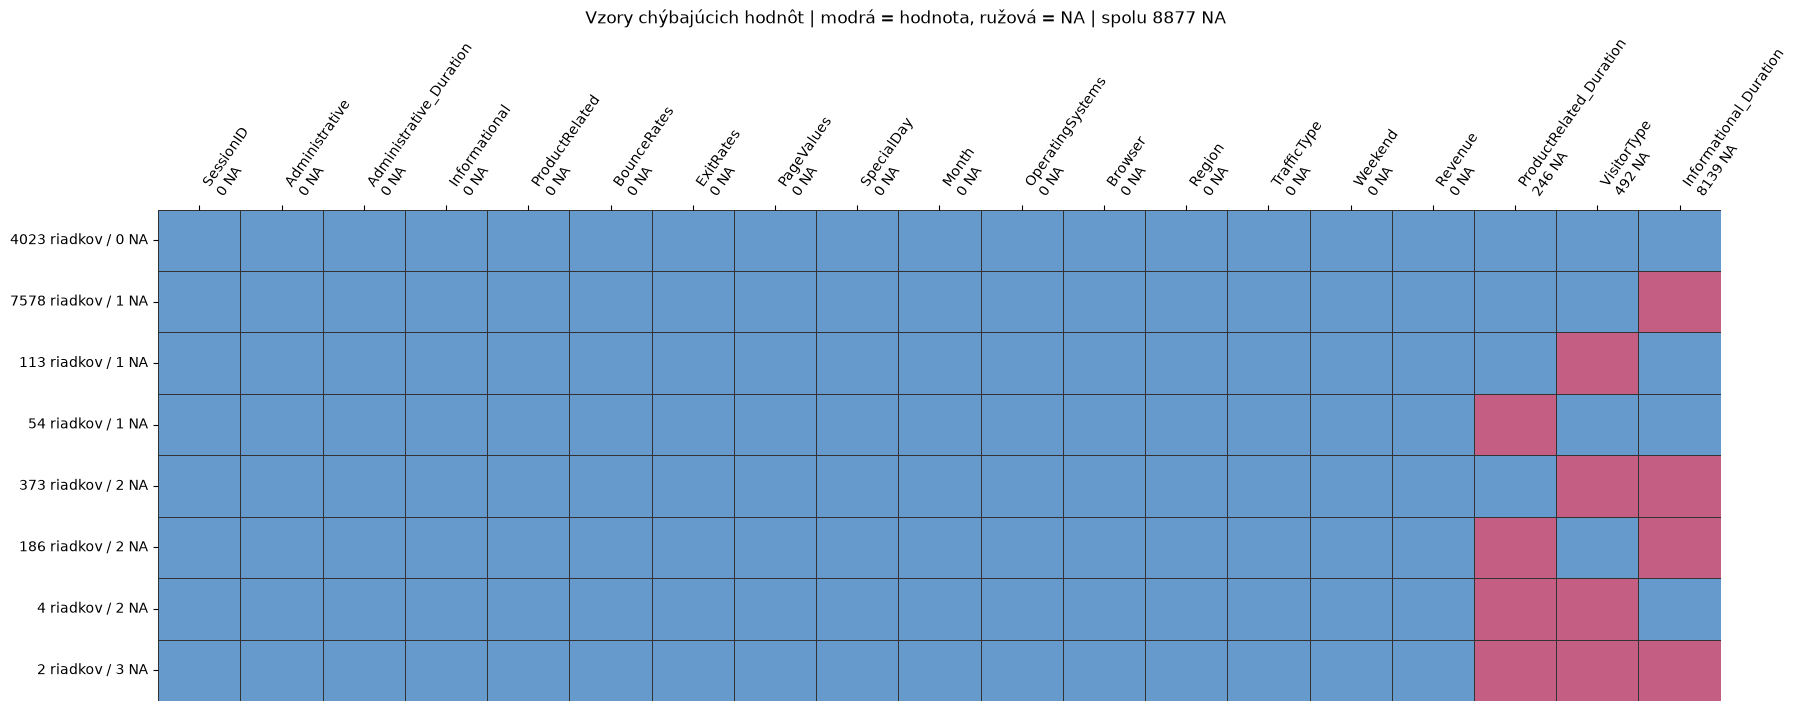

In [54]:
missing = data.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

V cca 2/3 (8139/12334) dat chyba hodnota (NA) v poslednom stlpci Informational_Duration, co neni ani vhodne doplnat/nahradzat, preto tento stlpec je jednoduchsie a lepsie dropnut. Riadky s cgybajucim ProductRelated_Duration a VisitorType odstranujem pre chybajuce hodnotu, co predstavuje 732 riadkov.

In [55]:
# dropnutie stlpca a riadkov
rows_to_drop = data["ProductRelated_Duration"].isna() | data["VisitorType"].isna()
data_clean = data.drop(index=data.index[rows_to_drop], columns="Informational_Duration").copy()

In [56]:
data_clean.describe()

,Administrative,Administrative_Duration,Informational,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000
mean,2.326437,112.502691,0.507801,35.006637,1199.481299,0.004117,0.042697,6.154971,0.061546,2.122662,2.351608,3.140160,4.077752
std,3.327508,901.008974,1.270743,127.664326,1918.490414,0.748188,0.048397,19.006150,0.199062,0.910592,1.708669,2.394896,4.027833
min,0.000000,-214.548633,0.000000,0.000000,-6423.973010,-42.953427,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,7.000000,185.000000,0.000000,0.014251,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,8.000000,0.000000,18.000000,604.000000,0.003014,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.600000,0.000000,38.000000,1467.654221,0.016667,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,33466.707646,24.000000,5258.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### removing outliers

In [57]:
def remove_outliers(df):
    counts = ["Administrative", "Informational", "ProductRelated"]
    nonnegative = counts + [
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "PageValues",
    ]

    bounds = {column: (0, np.inf) for column in nonnegative}
    bounds.update({
        "BounceRates": (0, 1),
        "ExitRates": (0, 1),
        "SpecialDay": (0, 1),

        # Hranice zvolené podľa výrazných medzier v týchto dátach.
        "Administrative_Duration": (0, 5000),
        "ProductRelated": (0, 1000),
    })

    categories = {
        "OperatingSystems": range(1, 9),
        "Browser": range(1, 14),
        "Region": range(1, 10),
        "TrafficType": range(1, 21),
        "Month": ["Feb", "Mar", "May", "June", "Jul",
                  "Aug", "Sep", "Oct", "Nov", "Dec"],
        "VisitorType": ["Returning_Visitor", "New_Visitor", "Other"],
        "Weekend": [True, False],
        "Revenue": [True, False],
    }

    valid = pd.Series(True, index=df.index)

    for column, (lower, upper) in bounds.items():
        if column not in df.columns:
            continue

        values = df[column]
        valid &= values.isna() | (
            values.between(lower, upper) & np.isfinite(values)
        )

        if column in counts:
            valid &= values.isna() | values.mod(1).eq(0)

    for column, allowed in categories.items():
        if column not in df.columns:
            continue

        values = df[column]
        valid &= values.isna() | values.isin(allowed)

    # Porovnávajú sa všetky stĺpce vrátane SessionID.
    return df.loc[valid].drop_duplicates().copy()

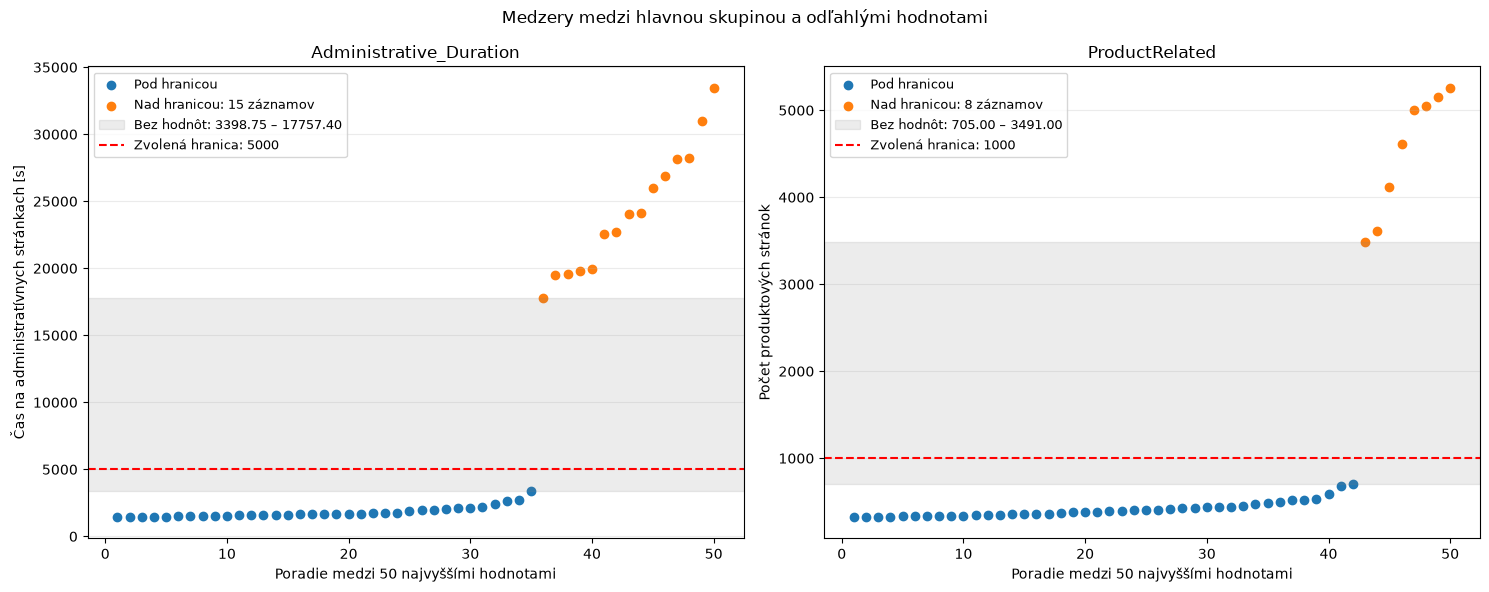

In [58]:

# Rovnaké odstránenie chýbajúcich hodnôt ako pri pôvodnom čistení.
plot_data = data.loc[
    data["ProductRelated_Duration"].notna()
    & data["VisitorType"].notna()
].copy()

settings = [
    ("Administrative_Duration", 5000, "Čas na administratívnych stránkach [s]"),
    ("ProductRelated", 1000, "Počet produktových stránok"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (column, threshold, ylabel) in zip(axes, settings):
    values = plot_data[column].dropna().sort_values().reset_index(drop=True)

    below = values[values <= threshold]
    above = values[values > threshold]
    lower_edge = below.max()
    upper_edge = above.min()

    # Zobrazíme 50 najvyšších hodnôt, aby bola medzera dobre viditeľná.
    tail = values.tail(50).reset_index(drop=True)
    ranks = tail.index + 1
    kept = tail <= threshold

    ax.scatter(
        ranks[kept], tail[kept],
        color="tab:blue", label="Pod hranicou",
    )
    ax.scatter(
        ranks[~kept], tail[~kept],
        color="tab:orange",
        label=f"Nad hranicou: {len(above)} záznamov",
    )

    ax.axhspan(
        lower_edge, upper_edge,
        color="gray", alpha=0.15,
        label=f"Bez hodnôt: {lower_edge:.2f} – {upper_edge:.2f}",
    )
    ax.axhline(
        threshold,
        color="red", linestyle="--",
        label=f"Zvolená hranica: {threshold}",
    )

    ax.set(
        title=column,
        xlabel="Poradie medzi 50 najvyššími hodnotami",
        ylabel=ylabel,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", fontsize=9)

fig.suptitle("Medzery medzi hlavnou skupinou a odľahlými hodnotami")
plt.tight_layout()
plt.show()

**odlahle zaznamy**

In [59]:
before = len(data_clean)
data_clean = remove_outliers(data_clean)

before, len(data_clean)

(11601, 11557)

Hranice 5 000s a 1 000 stranok lezie v medzerach medzi ostatnymi hodnotami a dvoma odlahlimy skupinami. Drop duplicates odstrani uplne identicke riadky, pricom navstevy s roznymi SessionID ponecha. Vysoke PageValues a dlhe ProductRelated_Duration ponechavam, lebo samotna velkost hodnoty nepreukazuje chybu a moze predstavovat hodnotny nakup alebo dlhu navstevu.

Po vycisteni sa pocet riadkov znizil z 11 601 na 11 557, kde sa odstrani 18 neplatnych zaznamov, 23 kladnych outlierov a 3 duplicity.

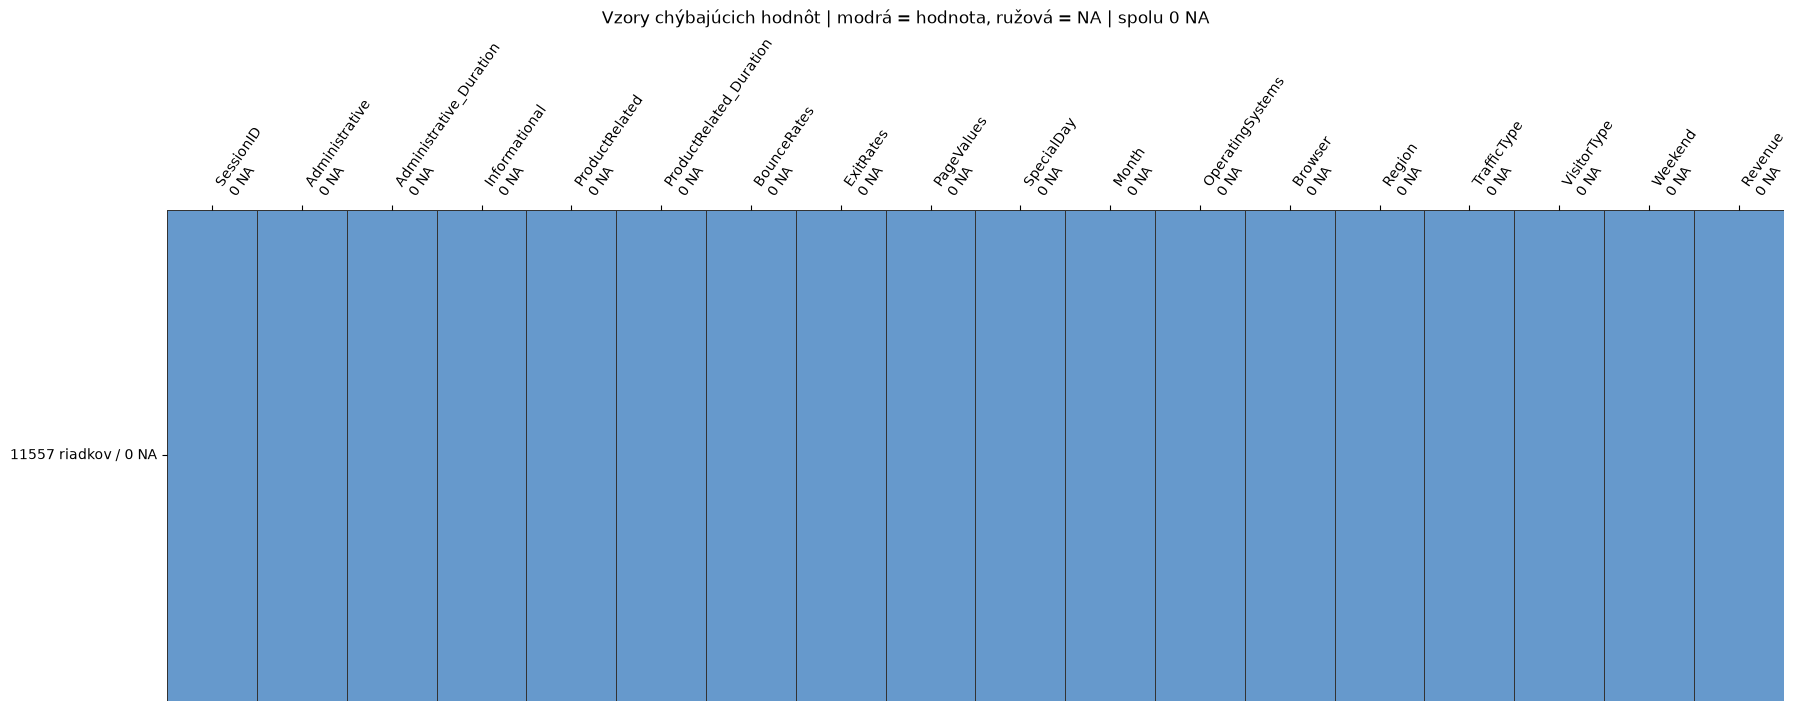

In [60]:
missing = data_clean.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data_clean.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

## VisitorType vs ProductRelated a PageValues

In [61]:
visitor_types = ["Returning_Visitor", "New_Visitor", "Other"]
visitor_data = data_clean[data_clean["VisitorType"].isin(visitor_types)].copy()
for metric in ["PageValues", "ProductRelated"]:
    visitor_data[f"log1p_{metric}"] = np.log1p(visitor_data[metric])

visitor_data["VisitorType"].value_counts().reindex(visitor_types)

VisitorType
Returning_Visitor    9887
New_Visitor          1592
Other                  78
Name: count, dtype: int64

pouzity $\log{(1 + x)}$ (log1p), kvoli normalizacii velmi odlahlych hodnot a obsahovani 0 hodnot, logaritmus 1+x zachova 0 na 0, normalizacia zachovana aj kvoli porovnaniu roznych skupin

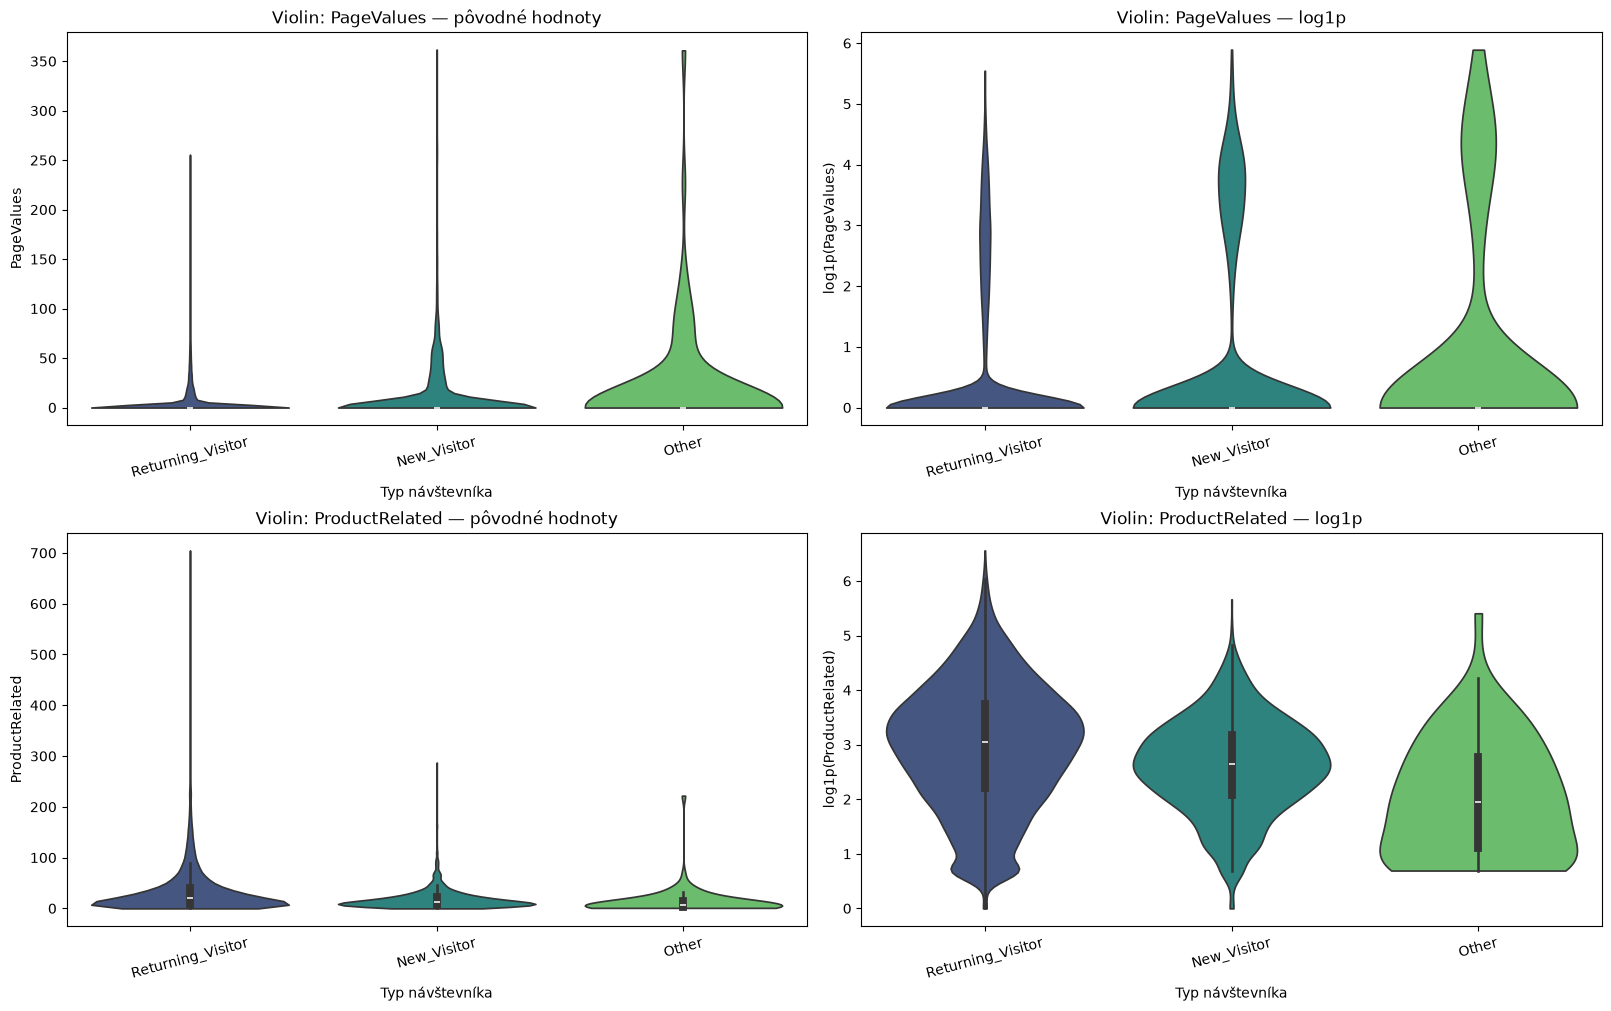

In [62]:
visitor_palette = dict(zip(visitor_types, sns.color_palette("viridis", len(visitor_types))))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.violinplot(
            data=visitor_data, x="VisitorType", y=value_column,
            order=visitor_types, hue="VisitorType", hue_order=visitor_types,
            palette=visitor_palette, dodge=False, legend=False,
            inner="box", cut=0,
            ax=ax,
        )
        ax.set(title=f"Violin: {metric} — {variant_label}",
               xlabel="Typ návštevníka", ylabel=value_label)
        ax.tick_params(axis="x", rotation=15)

plt.show()


Pri PageValues sa vo vsetkych skupinach vacsina hodnot sustreduje pri nule. Rozdelenia maju dlhe chvosty, kde sa tahaju k vysokym hodnotam. Transformacia $log1p$ zlepsuje zobrazenie hodnot, kde je vidno ze v skupine Other je hustota posunuta k vyssim hodnotam nez pri vracajucich sa navstevnikov.

Pri ProductRelated povodnu mierku vyrazne ovplyvnuju extremne hodnoty vracajucich sa navstevnikov. Po transformacii su rozdiely citatelnejsie, kde vracajuci sa navstevnivi maju najvyssi median a najnizsi ostatny typ navstevnikov. Vracajuci navstevnici navstevuju viac produktovo suvisiacich stranok.

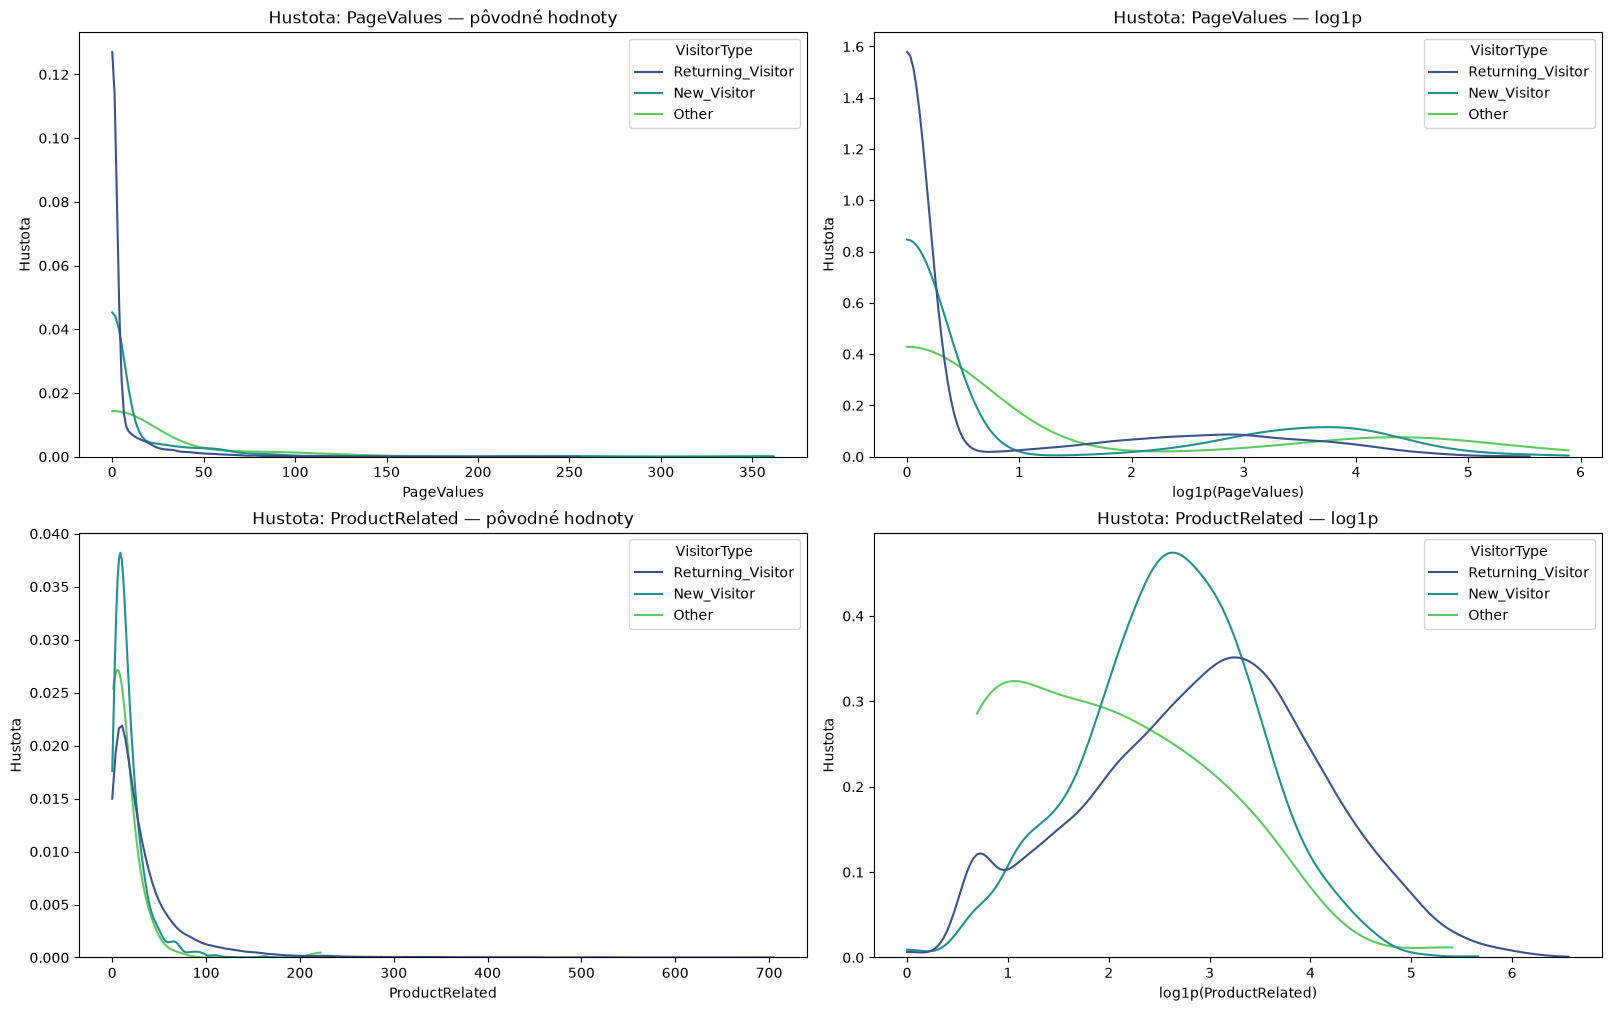

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.kdeplot(
            data=visitor_data, x=value_column, hue="VisitorType",
            hue_order=visitor_types, palette=visitor_palette,
            common_norm=False,
            cut=0,
            ax=ax,
        )
        ax.set(title=f"Hustota: {metric} — {variant_label}",
               xlabel=value_label, ylabel="Hustota")

plt.show()


Pri PageValues vidime vyrazny vrchol pri nule a dlhy chvost pri vsetkych skupinach. Pri nule je najhustejsia skupina vracajucich sa zakaznikov, pri skupinach New_Visitor a Other su hodnoty sirsie.

Pri ProductRelated je najvyssia hodnota v skupine novych zakaznikov v oblasti medzi 2 a 4 (os logaritmu skupiny). Skupina Other ma najhustejsiu hodnotu blizsie k nule a vracajuci sa zakaznici maju najhustejsiu hodnotu vo vyssich hodnotach.

## Month (mesiac poslednej navstevy) a Revenue

Porovnavam podiel sessionov ukoncenych nakupom v jednolivych mesiacoch. Pocet nakupov / pocet sessions v danom mesiaci. Mesacne podiely a chybove usecky, v ich 95% Wilson intervaloch spolahlivosti, co vyjadruje neistotu odhadu pri predpoklade nezavislych sessionov. V datasete chybaju data za mesiac januar a april.

Boxplot sumarizuje rozdelenie mesacnych podielov. 

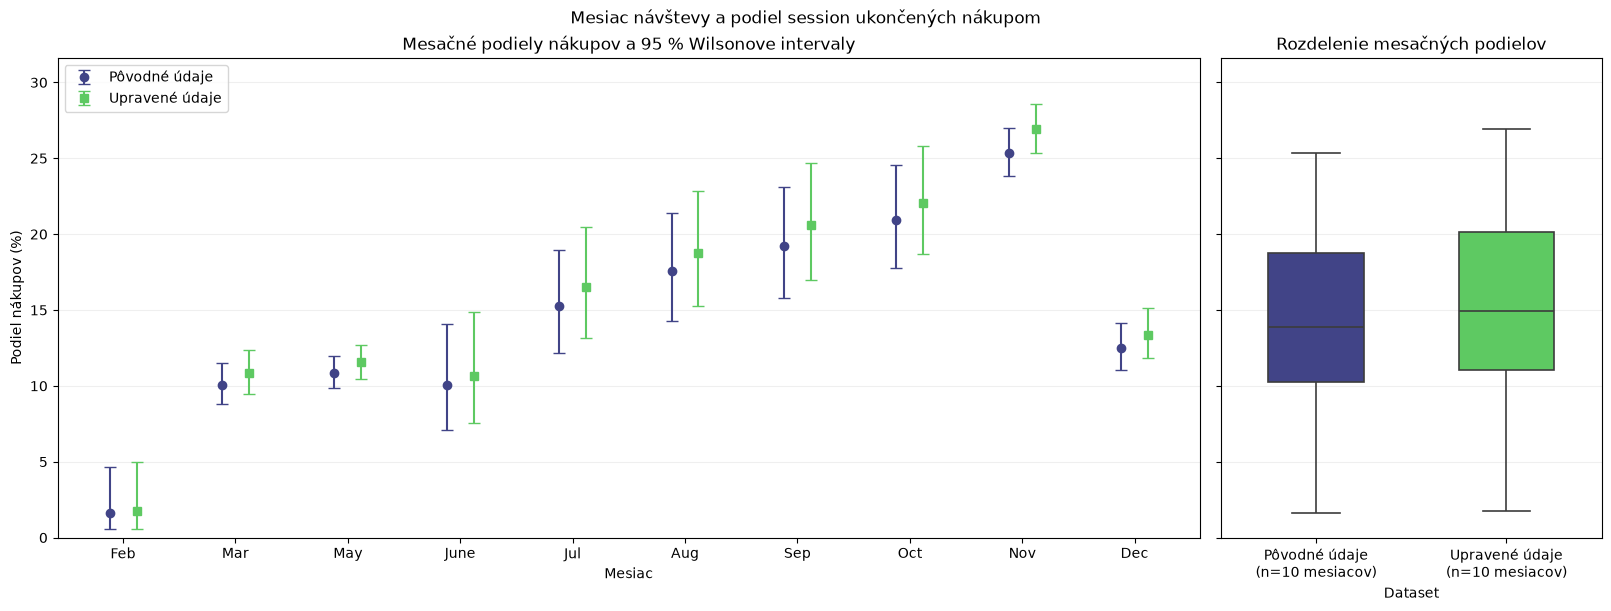

Pôvodné údaje                                           Upravené údaje  \
           sessions purchases purchase_rate ci_lower ci_upper       sessions   
Month                                                                          
Feb             185         3          1.62     0.55     4.66            173   
Mar            1907       192         10.07     8.80    11.50           1771   
May            3365       365         10.85     9.84    11.94           3161   
June            288        29         10.07     7.10    14.09            272   
Jul             432        66         15.28    12.19    18.98            400   
Aug             433        76         17.55    14.26    21.42            405   
Sep             448        86         19.20    15.82    23.10            418   
Oct             549       115         20.95    17.75    24.55            522   
Nov            2999       761         25.38    23.85    26.96           2821   
Dec            1727       216         12.51    11.03    14.15           1614   

                                                 
      purchases purchase_rate ci_lower ci_upper  
Month                                            
Feb           3          1.73     0.59     4.97  
Mar         192         10.84     9.48    12.37  
May         365         11.55    10.48    12.71  
June         29         10.66     7.53    14.89  
Jul          66         16.50    13.18    20.45  
Aug          76         18.77    15.26    22.85  
Sep          86         20.57    16.98    24.71  
Oct         115         22.03    18.69    25.78  
Nov         760         26.94    25.34    28.61  
Dec         216         13.38    11.81    15.13

In [64]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
datasets = {"Pôvodné údaje": data, "Upravené údaje": data_clean}
month_summary = {}
colors = plt.get_cmap("viridis")([0.2, 0.75])
positions = np.arange(len(month_order))
z = 1.959963984540054

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), sharey=True,
    gridspec_kw={"width_ratios": [3, 1]}, constrained_layout=True
)

for i, (label, frame) in enumerate(datasets.items()):
    monthly = (
        frame.dropna(subset=["Month", "Revenue"])
        .groupby("Month")["Revenue"]
        .agg(sessions="size", purchases="sum", purchase_rate="mean")
        .reindex(month_order)
    )
    sessions = monthly["sessions"]
    proportion = monthly["purchase_rate"]
    denominator = 1 + z**2 / sessions
    center = (proportion + z**2 / (2 * sessions)) / denominator
    half_width = (
        z * np.sqrt(
            proportion * (1 - proportion) / sessions
            + z**2 / (4 * sessions**2)
        ) / denominator
    )
    monthly["purchase_rate"] *= 100
    monthly["ci_lower"] = (center - half_width).clip(0, 1) * 100
    monthly["ci_upper"] = (center + half_width).clip(0, 1) * 100
    month_summary[label] = monthly

    rate = monthly["purchase_rate"]
    axes[0].errorbar(
        positions + (i - 0.5) * 0.24,
        rate,
        yerr=np.maximum(np.vstack([
            rate - monthly["ci_lower"], monthly["ci_upper"] - rate
        ]), 0),
        fmt=["o", "s"][i],
        linestyle="none",
        color=colors[i],
        capsize=4,
        markersize=6,
        label=label,
    )

axes[0].set(
    title="Mesačné podiely nákupov a 95 % Wilsonove intervaly",
    xlabel="Mesiac",
    ylabel="Podiel nákupov (%)",
    xticks=positions,
    xticklabels=month_order,
    ylim=(0, max(table["ci_upper"].max() for table in month_summary.values()) + 3),
)
axes[0].legend()

monthly_rates = pd.DataFrame({
    label: table["purchase_rate"] for label, table in month_summary.items()
})
sns.boxplot(
    data=monthly_rates, palette=list(colors), saturation=1,
    width=0.5, linewidth=1.2, ax=axes[1],
)
axes[1].set(title="Rozdelenie mesačných podielov", xlabel="Dataset", ylabel="")
axes[1].set_xticks(
    np.arange(len(datasets)),
    labels=[
        f"{label}\n(n={monthly_rates[label].count()} mesiacov)"
        for label in datasets
    ],
)
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)

fig.suptitle("Mesiac návštevy a podiel session ukončených nákupom")
plt.show()

pd.concat(month_summary, axis=1).round(2)


Najvyssi podiel nakupov je za mesiac november, priblizne 25.4% v neupravenych a v upravenych 26.9% datach. Najnizsie je za mesiac februar, kde dosahuje podiel iba 1.6% a 1.7%.

Intervaly spolahlivosti spresnuju informaciu o presnosti odhadov, kde zavisi od poctu sessions aj od podielu nakupov. Maj ma uzsi interval ako mesiac august, ktory obsahuje menej sessionov.

Pri cisteni boli odstranene iba sessiony bez nakupu, pocet nakupov preto ostal rovnaky, zatial co sessiony klesli, co zvysilo podiel nakupov v upravenych datach.

### Correlation of session and purchase by month

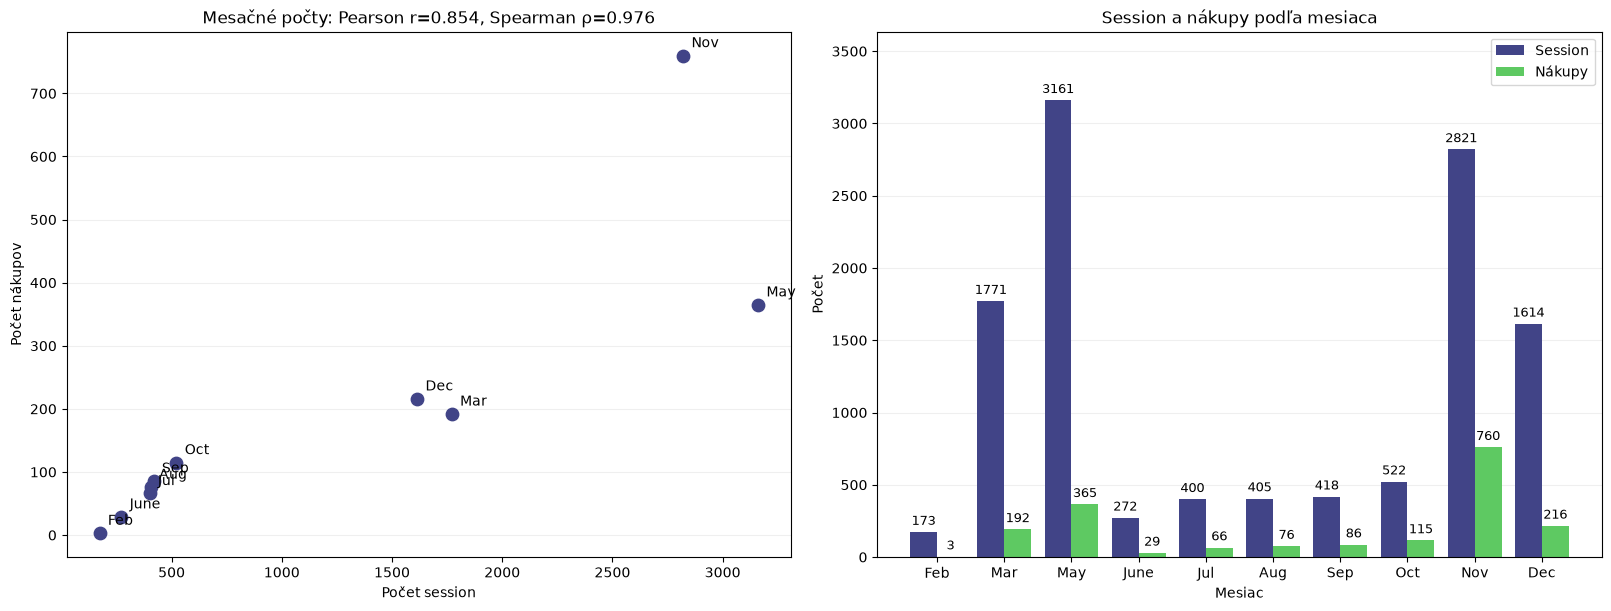

,Počet session,Počet nákupov,Podiel nákupov (%),Pearson,Spearman
Mesiac,,,,,
Feb,173,3,1.73,—,—
Mar,1771,192,10.84,—,—
May,3161,365,11.55,—,—
June,272,29,10.66,—,—
Jul,400,66,16.50,—,—
Aug,405,76,18.77,—,—
Sep,418,86,20.57,—,—
Oct,522,115,22.03,—,—
Nov,2821,760,26.94,—,—


In [65]:
# Použije mesačné počty vypočítané v month_summary.
monthly = month_summary["Upravené údaje"][["sessions", "purchases"]].dropna()

pearson = monthly["sessions"].corr(monthly["purchases"], method="pearson")
spearman = monthly["sessions"].corr(monthly["purchases"], method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Korelačný graf – jeden bod predstavuje jeden mesiac.
axes[0].scatter(
    monthly["sessions"], monthly["purchases"], s=80, color=colors[0]
)

for month, row in monthly.iterrows():
    axes[0].annotate(
        month, (row["sessions"], row["purchases"]),
        xytext=(6, 6), textcoords="offset points"
    )

axes[0].set(
    title=f"Mesačné počty: Pearson r={pearson:.3f}, Spearman ρ={spearman:.3f}",
    xlabel="Počet session",
    ylabel="Počet nákupov"
)

# Stĺpcový graf.
x = np.arange(len(monthly))
for offset, column, label, color in [
    (-0.2, "sessions", "Session", colors[0]),
    (0.2, "purchases", "Nákupy", colors[1])
]:
    bars = axes[1].bar(
        x + offset, monthly[column], width=0.4, label=label, color=color
    )
    axes[1].bar_label(bars, padding=3, fontsize=9)

axes[1].set(
    title="Session a nákupy podľa mesiaca",
    xlabel="Mesiac", ylabel="Počet",
    xticks=x, xticklabels=monthly.index
)
axes[1].margins(y=0.15)
axes[1].legend()

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

plt.show()

# V každom mesiaci je iba jeden pár počtov: korelácia je nedefinovaná.
# Posledný riadok obsahuje korelácie naprieč mesiacmi.
table = monthly.rename(columns={
    "sessions": "Počet session",
    "purchases": "Počet nákupov"
}).copy()

table.index.name = "Mesiac"
table["Podiel nákupov (%)"] = (
    table["Počet nákupov"] / table["Počet session"] * 100
)
table["Pearson"] = np.nan
table["Spearman"] = np.nan

table.loc["Spolu / priemerný podiel / korelácie medzi mesiacmi"] = [
    monthly["sessions"].sum(),
    monthly["purchases"].sum(),
    table["Podiel nákupov (%)"].mean(),
    pearson,
    spearman
]

display(table.style.format({
    "Počet session": "{:.0f}",
    "Počet nákupov": "{:.0f}",
    "Podiel nákupov (%)": "{:.2f}",
    "Pearson": "{:.3f}",
    "Spearman": "{:.3f}"
}, na_rep="—"))

Pearsonova korelacia r = 0.853 naznacuje silny linearny vztah. Spearmanova korelacia $\rho = 0.976$ ukazuje, ze mesiace s vyssou navstevnostou maju takmer vzdy aj vyssi pocet nakupov.

Maj mal najviac sessionov 3 171 ale nakupom skoncilo 365, podiel 11.5%. November mal menej sessionov 2 826 no najviac nakupov 756, co je aj najvyssi podiel nakupov 26.9%. Najnizsie podiel dosiahol za mesiac februar a to 1.7%.

## ProductRelated a ExitRates

Hexbin graf ukazuje pocet produktovych stranok oproti priemernej miere odchodu zo stranok navstyvenych v sessions. Pouzivam log1p, co zachova nuly a zlepsuje citatelnost velkho rozsahu. Farba vyjadruje pocet sessionov v hexagone.

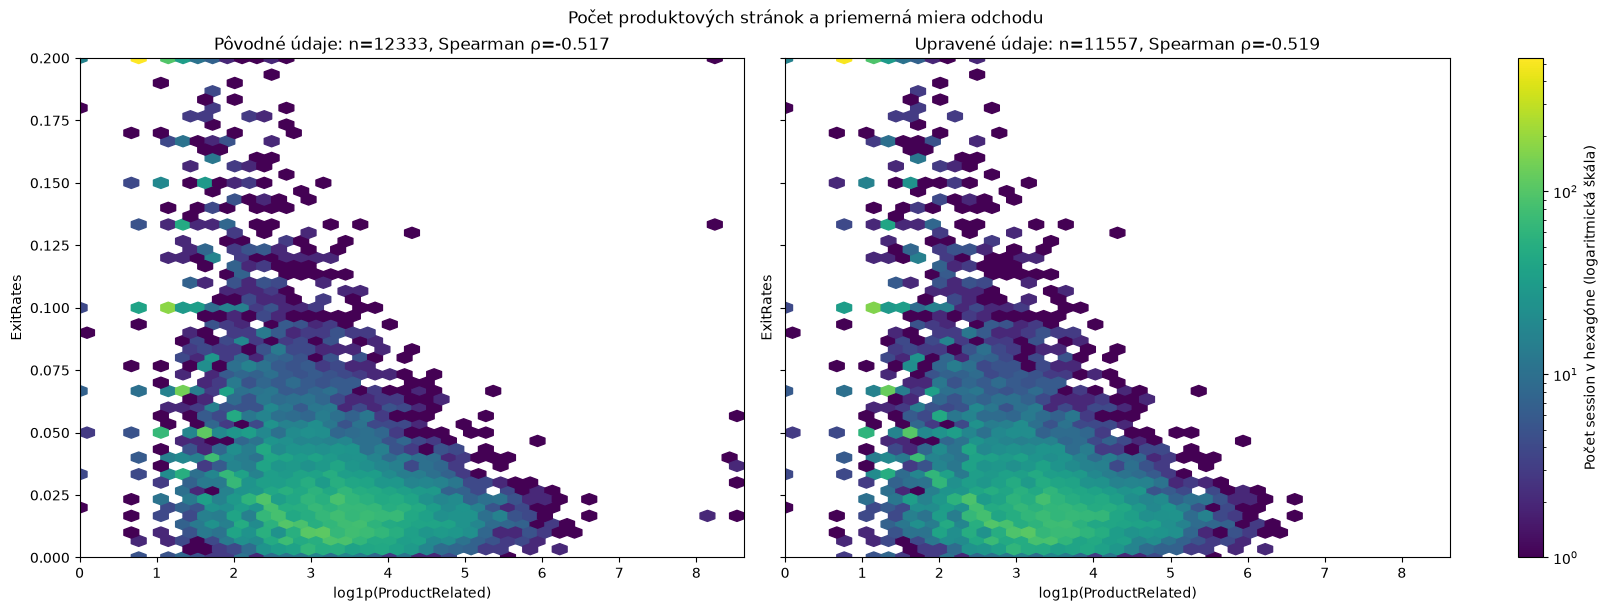

,Počet session,Spearman,Medián ExitRates (0–1 produktových stránok),Medián ExitRates (>50 produktových stránok)
Dataset,,,,
Pôvodné údaje,12333,-0.517,0.2,0.017
Upravené údaje,11557,-0.519,0.2,0.017


In [66]:
from matplotlib.colors import LogNorm

datasets = {"Pôvodné údaje": data, "Upravené údaje": data_clean}
exit_pairs = {
    label: frame[["ProductRelated", "ExitRates"]].dropna()
    for label, frame in datasets.items()
}
extent = (
    0,
    max(np.log1p(pair["ProductRelated"]).max() for pair in exit_pairs.values()),
    0,
    max(pair["ExitRates"].max() for pair in exit_pairs.values()),
)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), sharex=True, sharey=True, constrained_layout=True
)
hexagons = []
exit_summary = []

for ax, (label, pair) in zip(axes, exit_pairs.items()):
    correlation = pair.corr(method="spearman").loc["ProductRelated", "ExitRates"]
    hexagons.append(ax.hexbin(
        np.log1p(pair["ProductRelated"]),
        pair["ExitRates"],
        gridsize=(45, 30),
        extent=extent,
        mincnt=1,
        cmap="viridis",
    ))
    ax.set(
        title=f"{label}: n={len(pair)}, Spearman ρ={correlation:.3f}",
        xlabel="log1p(ProductRelated)",
        ylabel="ExitRates",
        xlim=extent[:2],
        ylim=extent[2:],
    )
    exit_summary.append({
        "Dataset": label,
        "Počet session": len(pair),
        "Spearman": correlation,
        "Medián ExitRates (0–1 produktových stránok)": pair.loc[
            pair["ProductRelated"].between(0, 1), "ExitRates"
        ].median(),
        "Medián ExitRates (>50 produktových stránok)": pair.loc[
            pair["ProductRelated"] > 50, "ExitRates"
        ].median(),
    })

density_norm = LogNorm(
    vmin=1, vmax=max(2, max(grid.get_array().max() for grid in hexagons))
)
for grid in hexagons:
    grid.set_norm(density_norm)

fig.colorbar(
    hexagons[0], ax=axes,
    label="Počet session v hexagóne (logaritmická škála)"
)
fig.suptitle("Počet produktových stránok a priemerná miera odchodu")
plt.show()

pd.DataFrame(exit_summary).set_index("Dataset").round(3)

S rastucim poctom navstivenych produktovych stranok ma priemerna miera odchodu sa znizovat. Vztah ostava podobny pred aj po cisteni, kde to naznacuje Spearmanova korelacia, ktora je priblizne -0.52. Nepreukazuje sa, ze viac produktovych stranok priamo sposobuje nizsiu mieru odchodu. Median pre ExitRates pri 0-1 produktovych strankach je 0.2 ale 0.017 pri viac ako 50 produktovych strankach.

## Correlation of ProductRelated and time on them

Počet session: 11557 | Pearson r = 0.861 | Spearman ρ = 0.884


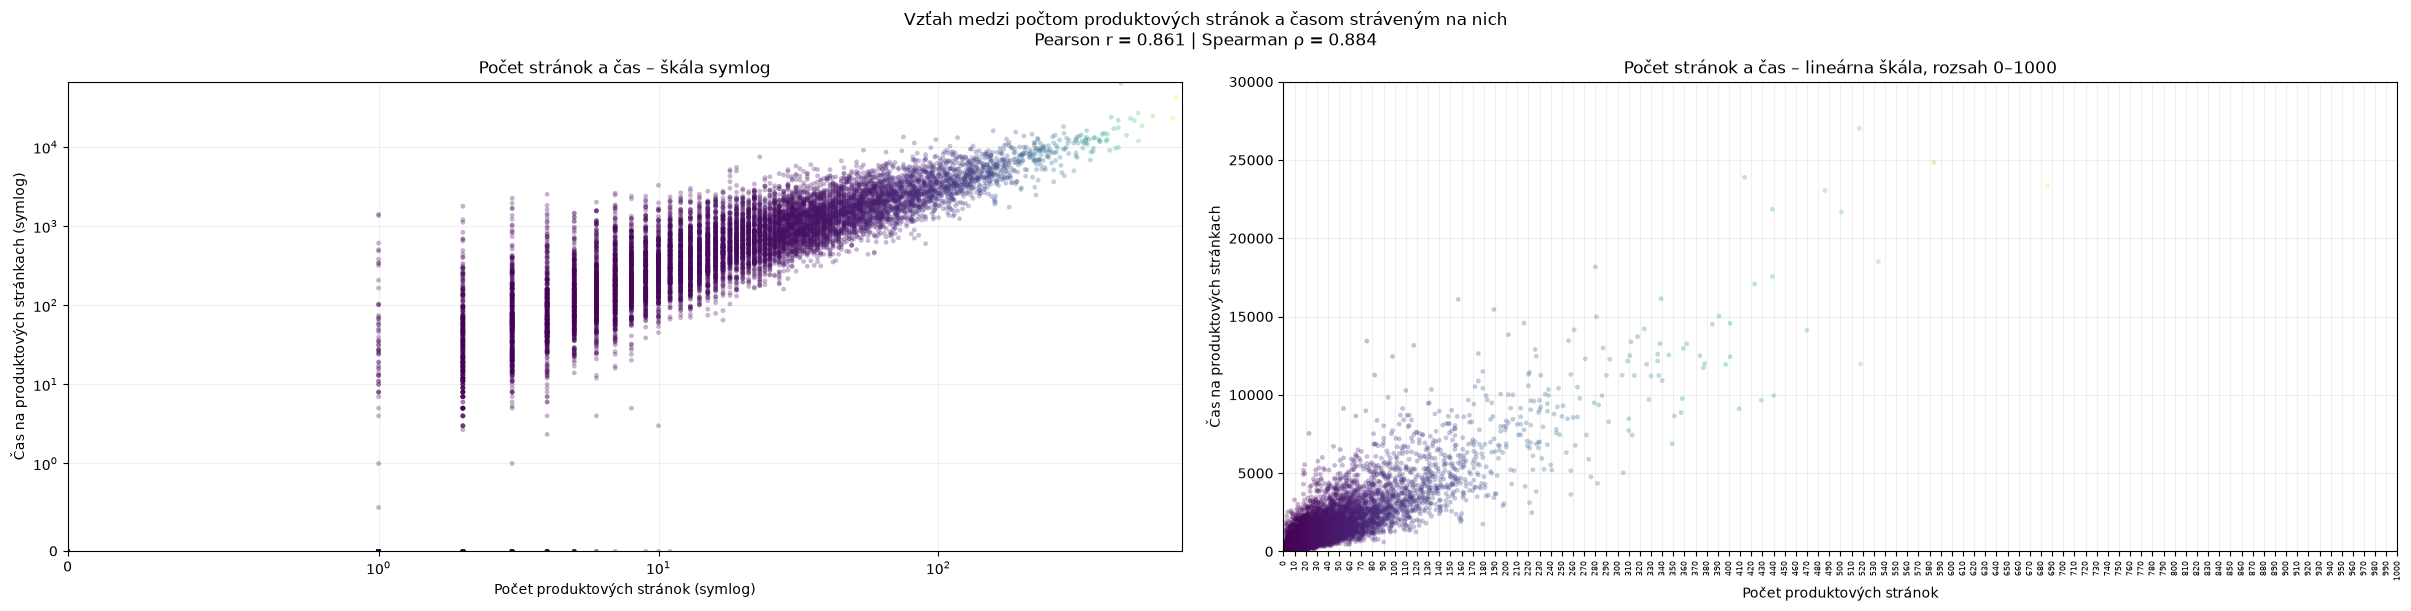

Počet session s časom nad 30 000: 2


,SessionID,ProductRelated,ProductRelated_Duration
0,S-108071,449.0,63973.52223
1,S-105152,705.0,43171.23338


In [67]:
product_pair = data_clean[
    ["ProductRelated", "ProductRelated_Duration"]
].dropna()

pearson_matrix = product_pair.corr(method="pearson")
pearson = pearson_matrix.iloc[0, 1]
spearman = product_pair.corr(method="spearman").iloc[0, 1]

print(
    f"Počet session: {len(product_pair)} | "
    f"Pearson r = {pearson:.3f} | Spearman ρ = {spearman:.3f}"
)

fig, axes = plt.subplots(
    1, 2, figsize=(24, 6), constrained_layout=True
)

for ax in axes[:2]:
    sns.scatterplot(
        data=product_pair,
        x="ProductRelated",
        y="ProductRelated_Duration",
        hue="ProductRelated",
        palette="viridis",
        hue_norm=(
            product_pair["ProductRelated"].min(),
            product_pair["ProductRelated"].max()
        ),
        legend=False,
        alpha=0.3,
        s=12,
        edgecolor="none",
        ax=ax,
    )
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)

# Prvý graf: obe osi v škále symlog, všetky hodnoty.
axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)
axes[0].set(
    title="Počet stránok a čas – škála symlog",
    xlabel="Počet produktových stránok (symlog)",
    ylabel="Čas na produktových stránkach (symlog)",
)

# Druhý graf: lineárne osi, os x po 10 do 1000.
# Body s počtom stránok nad 1000 sú mimo zobrazeného rozsahu.
axes[1].set_xscale("linear")
axes[1].set_yscale("linear")
axes[1].set_xlim(0, 1000)
axes[1].set_ylim(0, 30_000)
axes[1].set_xticks(np.arange(0, 1001, 10))
axes[1].tick_params(axis="x", labelrotation=90, labelsize=6)
axes[1].set(
    title="Počet stránok a čas – lineárna škála, rozsah 0–1000",
    xlabel="Počet produktových stránok",
    ylabel="Čas na produktových stránkach",
)

# Tretí graf: korelácia vypočítaná zo všetkých pôvodných hodnôt.
# sns.heatmap(
#     pearson_matrix,
#     annot=True,
#     fmt=".3f",
#     cmap="viridis",
#     vmin=-1,
#     vmax=1,
#     square=True,
#     ax=axes[2],
# )
# axes[2].set_title(f"Pearsonova korelácia: r = {pearson:.3f}")

fig.suptitle(
    "Vzťah medzi počtom produktových stránok a časom stráveným na nich\n"
    f"Pearson r = {pearson:.3f} | Spearman ρ = {spearman:.3f}"
)
plt.show()

# Session s časom nad 30 000, bez ohľadu na počet stránok.
duration_outliers = data_clean.loc[
    data_clean["ProductRelated_Duration"] > 30_000,
    ["SessionID", "ProductRelated", "ProductRelated_Duration"]
].sort_values("ProductRelated_Duration", ascending=False)

print(f"Počet session s časom nad 30 000: {len(duration_outliers)}")

# Každý riadok predstavuje jednu session prekračujúcu limit.
display(duration_outliers.reset_index(drop=True))

Graf ukazuje, ze s rastucim poctom navstivenych produktovych stranok rastie aj cas straveny na nich. Pearsonova korelacia je 0.304, co naznacuje slabsiu linearnu zavislost. Spearmanova korelacia 0.883 ukazuje silny vztah, vyssiemu poctu stranok vacsinou pripada dlhsi cas, hoci tento rast nie je rovnomerny.

Graf so skalou `symlog` umoznuje ukazat extremne hodnoty a lepsie odhaluje rastuci trend. Linearny graf ukazuje, ze vacsina sessionov sa sustreduje pri nizsich poctoch stranok a kratsom case. 

Pri rovnakom pocte stranok sa cas medzi sessionami vyrazne lisi. Viditelne su aj extremne hodnoty s vysokym poctom stranok a pomerne kratkym casom, ktore mozu ovplyvnovat Pearsonovu korelaciu. Pocet produktovych stranok suvisi s casom navstevy, ale sam nestaci na jeho presny odhad.

# Classification

## data separation

In [90]:
RANDOM_STATE = 42
USE_CROSS_VALIDATION = False  
CV_FOLDS = 5
N_JOBS = -1               
TOP_FEATURES = 10
PERMUTATION_REPEATS = 10

SPLIT_RATIOS = {
    "70/15/15": (0.70, 0.15, 0.15),
    "80/10/10": (0.80, 0.10, 0.10),
    "70/10/20": (0.70, 0.10, 0.20),
    "60/10/30": (0.60, 0.10, 0.30),
}

skf = StratifiedKFold(
    n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE
)



In [80]:
X = data_clean.drop(columns=["SessionID", "Revenue"]).copy()
y = data_clean["Revenue"].astype(int).copy()

# Weekend má iba dve možnosti, preto stačí jeden binárny stĺpec.
X["Weekend"] = X["Weekend"].map({False: 0, True: 1})
binary_columns = ["Weekend"]

# Tieto číselné identifikátory tiež označujú kategórie, nie veľkosť.
category_codes = ["OperatingSystems", "Browser", "Region", "TrafficType"]
categorical_columns = list(dict.fromkeys(
    X.select_dtypes(include=["object", "string", "category", "bool"])
    .columns.tolist()
    + [column for column in category_codes if column in X.columns]
))
categorical_columns = [
    column for column in categorical_columns if column not in binary_columns
]
numeric_columns = [
    column for column in X.columns
    if column not in categorical_columns + binary_columns
]


X.shape, y.shape, categorical_columns, binary_columns


((11557, 16),
 (11557,),
 ['Month',
  'VisitorType',
  'OperatingSystems',
  'Browser',
  'Region',
  'TrafficType'],
 ['Weekend'])

In [ ]:
y.value_counts(normalize=True) # podiel tried reveniu

Revenue
0    0.834905
1    0.165095
Name: proportion, dtype: float64

## train, val, test split

In [81]:
def split_dataset(X, y, ratios):
    train_ratio, val_ratio, test_ratio = ratios
    if not np.isclose(sum(ratios), 1) or min(ratios) <= 0:
        raise ValueError("Pomery musia byť kladné a ich súčet musí byť 1.")

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_ratio,
        stratify=y, random_state=RANDOM_STATE,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=val_ratio / (train_ratio + val_ratio),
        stratify=y_train_val, random_state=RANDOM_STATE,
    )
    return {
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "y_train": y_train, "y_val": y_val, "y_test": y_test,
    }

experiment_splits = {
    name: split_dataset(X, y, ratios)
    for name, ratios in SPLIT_RATIOS.items()
}

# Bežné premenné pre vlastné pokusy v ďalších bunkách notebooku.
SELECTED_SPLIT = "70/15/15"
selected_data = experiment_splits[SELECTED_SPLIT]
X_train, X_val, X_test = (
    selected_data[key] for key in ["X_train", "X_val", "X_test"]
)
y_train, y_val, y_test = (
    selected_data[key] for key in ["y_train", "y_val", "y_test"]
)


len(y_train), len(y_val), len(y_test)


(8089, 1734, 1734)

Rozdelenie dat na trenovacie, testovacie a validacne, kde vyuzim aj stratify na zachovanie pomeru voci Revenue (zachovanie tak isteho pomeru nakupu v train, val a test mnozine). Pocty sa mozu mierne lisit od pomerov pre zaokruhlenie na cele riadky.

## encoding discrete cols

In [77]:
categorical_preparation = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])


One-Hot encoder vytvori samostatne binarne stlpce pre kazdu kategoriu, co je vhodne pre diskretne data (kategoricke). Nezachovava vztah, zavislost, poradie ani vzdialenost od ostatnych kategorii - mali by byt nezavisle, ale nezarucuje sa to. handle unknown umozni spracovat aj kategoriu, ktora sa v treningu nevyskytla a imputer doplni pripadne chybajuce hodnoty najcastejsiou kategoriou, ktora sa vyskytla v treningu.

## scaling

In [82]:
numeric_preparation = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preparation, numeric_columns),
    ("categorical", categorical_preparation, categorical_columns),
    ("binary", SimpleImputer(strategy="most_frequent"), binary_columns),
], remainder="drop")

def make_model_pipeline(classifier):
    return Pipeline([
        ("preprocessing", clone(preprocessor)),
        ("model", clone(classifier)),
    ])


StandardScaler skaluje ciselne vlastnosti na priblizne nulovy priemer a jednotkovy rozptyl (napriklad aby sa cas v sekundach neprevazoval nad mierami odchodu pri fitovani logistickej regresii). Diskretne stlpce ponechavam v 0/1, pripadne chybajuce hodnoty sa doplnia modusom.

Vsetko je organizovane v Pipeline, aby sa kodovanie, skalovanie, imputacia vyuzivalo pri kazdom folde trenovania.

## modely

In [86]:
parameters = {
    "max_features": [4, 7, 10, 13],
    "min_samples_leaf": [1, 3, 5, 7],
    "max_depth": [5, 10, 15, 20],
}

model_configs = {
    "RandomForest": {
        "classifier": RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE, n_jobs=1,
        ),
        # Prefix model__ je potrebný, pretože klasifikátor je v Pipeline.
        "grid": {f"model__{name}": values for name, values in parameters.items()},
    },
    "LogisticRegression": {
        "classifier": LogisticRegression(
            solver="lbfgs", max_iter=3000, random_state=RANDOM_STATE,
        ),
        "grid": {
            "model__C": np.logspace(-5, 0, 6),
            "model__class_weight": [None, "balanced"],
        },
    },
    "DecisionTree": {
        "classifier": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "grid": {
            "model__max_depth": [3, 5, 10, 15, None],
            "model__min_samples_leaf": [1, 5],
        },
    },
}

for name, config in model_configs.items():
    print(f"{name}: {len(ParameterGrid(config['grid']))} kombinácií")


RandomForest: 64 kombinácií
LogisticRegression: 12 kombinácií
DecisionTree: 10 kombinácií


## GridSearchCV

In [87]:
def train_with_grid_search(config, split):
    pipeline = make_model_pipeline(config["classifier"])

    if USE_CROSS_VALIDATION:
        X_search, y_search = split["X_train"], split["y_train"]
        if y_search.value_counts().min() < CV_FOLDS:
            raise ValueError("Každá trieda potrebuje aspoň CV_FOLDS riadkov.")
        search_cv = skf
    else:
        # -1 = tréningový riadok, 0 = validačný riadok jediného splitu.
        X_search = pd.concat([split["X_train"], split["X_val"]])
        y_search = pd.concat([split["y_train"], split["y_val"]])
        fold_ids = np.concatenate([
            np.full(len(split["y_train"]), -1),
            np.zeros(len(split["y_val"]), dtype=int),
        ])
        search_cv = PredefinedSplit(fold_ids)

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["grid"],
        scoring="accuracy",
        cv=search_cv,
        refit=False,
        return_train_score=True,
        n_jobs=N_JOBS,
        error_score="raise",
        verbose=1,
    )
    search.fit(X_search, y_search)

    # Finálny model sa v oboch režimoch učí iba na tréningovej množine.
    fitted_model = clone(pipeline).set_params(**search.best_params_)
    fitted_model.fit(split["X_train"], split["y_train"])
    return search, fitted_model


Pri cross-validation sa vyberaju parametre podla priemernej accuracy v 5 stratified k-folds treningovej mnoziny.

## experiments, fit and eval

### fit

In [91]:
experiment_rows = []
trained_models = {}
grid_searches = {}

for split_name, split in experiment_splits.items():
    for model_name, config in model_configs.items():
        print(f"\nRozdelenie {split_name} | {model_name}")
        search, fitted_model = train_with_grid_search(config, split)
        key = (split_name, model_name)
        trained_models[key] = fitted_model
        grid_searches[key] = search

        train_prediction = fitted_model.predict(split["X_train"])
        val_prediction = fitted_model.predict(split["X_val"])

        experiment_rows.append({
            "Rozdelenie": split_name,
            "Model": model_name,
            "Train n": len(split["y_train"]),
            "Val n": len(split["y_val"]),
            "Test n": len(split["y_test"]),
            "Train accuracy": accuracy_score(split["y_train"], train_prediction),
            "Val accuracy": accuracy_score(split["y_val"], val_prediction),
            "Grid accuracy": search.best_score_,
            "Grid std": search.cv_results_["std_test_score"][search.best_index_],
            "Najlepšie parametre": search.best_params_,
        })
        print("GridSearchCV.best_params_:", search.best_params_)
        print("GridSearchCV.best_score_:", search.best_score_)

results = pd.DataFrame(experiment_rows)

# Model vyberáme pred vyhodnotením na testovacích dátach.
best_row = results.sort_values(
    ["Val accuracy", "Grid accuracy"], ascending=False, kind="stable"
).iloc[0]
best_key = (best_row["Rozdelenie"], best_row["Model"])
best_model = trained_models[best_key]
best_split = experiment_splits[best_key[0]]

# Testy teraz iba vyhodnotíme; nepoužijeme ich na zmenu best_key.
for row in experiment_rows:
    key = (row["Rozdelenie"], row["Model"])
    split = experiment_splits[key[0]]
    prediction = trained_models[key].predict(split["X_test"])
    row.update({
        "Test accuracy": accuracy_score(split["y_test"], prediction),
        "Test balanced accuracy": balanced_accuracy_score(split["y_test"], prediction),
        "Test F1": f1_score(split["y_test"], prediction, zero_division=0),
        "Test recall": recall_score(split["y_test"], prediction, zero_division=0),
        "Baseline test accuracy": accuracy_score(
            split["y_test"],
            np.full(len(prediction), split["y_train"].mode().iloc[0]),
        ),
    })

results = pd.DataFrame(experiment_rows)
results["Train-test rozdiel"] = results["Train accuracy"] - results["Test accuracy"]
experiment_table = results.drop(columns="Najlepšie parametre")
display(experiment_table.round(4))

print("Vybraný model a rozdelenie:", best_key)
print("Vybrané parametre:", grid_searches[best_key].best_params_)
print("Grid accuracy =", f"priemer {CV_FOLDS}-fold CV" if USE_CROSS_VALIDATION
      else "accuracy na validačnej množine")
if not USE_CROSS_VALIDATION:
    print("Grid std = 0 znamená jediný validačný split, nie nulovú neistotu.")



Rozdelenie 70/15/15 | RandomForest
Fitting 1 folds for each of 64 candidates, totalling 64 fits
GridSearchCV.best_params_: {'model__max_depth': 15, 'model__max_features': 10, 'model__min_samples_leaf': 3}
GridSearchCV.best_score_: 0.8967704728950404

Rozdelenie 70/15/15 | LogisticRegression
Fitting 1 folds for each of 12 candidates, totalling 12 fits
GridSearchCV.best_params_: {'model__C': np.float64(0.1), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8748558246828143

Rozdelenie 70/15/15 | DecisionTree
Fitting 1 folds for each of 10 candidates, totalling 10 fits
GridSearchCV.best_params_: {'model__max_depth': 5, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.8927335640138409

Rozdelenie 80/10/10 | RandomForest
Fitting 1 folds for each of 64 candidates, totalling 64 fits
GridSearchCV.best_params_: {'model__max_depth': 15, 'model__max_features': 13, 'model__min_samples_leaf': 3}
GridSearchCV.best_score_: 0.8987889273356401

Rozdelenie 80/10/10 | LogisticRegression

,Rozdelenie,Model,Train n,Val n,Test n,Train accuracy,Val accuracy,Grid accuracy,Grid std,Test accuracy,Test balanced accuracy,Test F1,Test recall,Baseline test accuracy,Train-test rozdiel
0,70/15/15,RandomForest,8089,1734,1734,0.9498,0.8968,0.8968,0.0,0.8899,0.7404,0.6078,0.5175,0.8351,0.0600
1,70/15/15,LogisticRegression,8089,1734,1734,0.8795,0.8749,0.8749,0.0,0.8760,0.6634,0.4794,0.3462,0.8351,0.0035
2,70/15/15,DecisionTree,8089,1734,1734,0.9119,0.8927,0.8927,0.0,0.8795,0.7146,0.5618,0.4685,0.8351,0.0324
3,80/10/10,RandomForest,9245,1156,1156,0.9562,0.8988,0.8988,0.0,0.8867,0.7432,0.6066,0.5288,0.8348,0.0695
4,80/10/10,LogisticRegression,9245,1156,1156,0.8792,0.8798,0.8798,0.0,0.8780,0.6708,0.4946,0.3613,0.8348,0.0012
5,80/10/10,DecisionTree,9245,1156,1156,0.8982,0.8875,0.8875,0.0,0.8832,0.7516,0.6110,0.5550,0.8348,0.0150
6,70/10/20,RandomForest,8089,1156,2312,0.9478,0.9118,0.9118,0.0,0.8966,0.7607,0.6406,0.5576,0.8348,0.0512
7,70/10/20,LogisticRegression,8089,1156,2312,0.8796,0.8780,0.8780,0.0,0.8763,0.6666,0.4856,0.3534,0.8348,0.0033
8,70/10/20,DecisionTree,8089,1156,2312,0.8971,0.9014,0.9014,0.0,0.8854,0.7602,0.6230,0.5733,0.8348,0.0118
9,60/10/30,RandomForest,6933,1156,3468,0.9358,0.8997,0.8997,0.0,0.8971,0.7613,0.6419,0.5585,0.8348,0.0388


Vybraný model a rozdelenie: ('70/10/20', 'RandomForest')
Vybrané parametre: {'model__max_depth': 10, 'model__max_features': 13, 'model__min_samples_leaf': 1}
Grid accuracy = accuracy na validačnej množine
Grid std = 0 znamená jediný validačný split, nie nulovú neistotu.


Tabulka ma 12 riadkov s roznymi kombinaciami experimentovania. Vyhodnocuju sa 3 modely na 4 rozdeleniach s trenovaciou, validacnou a testovacou uspesnostou. Najlepsi model vyberam podla validation accuracy a pri zhode podla vysledku z grid searchu.

```

Rozdelenie 70/15/15 | RandomForest
Fitting 1 folds for each of 64 candidates, totalling 64 fits
GridSearchCV.best_params_: {'model__max_depth': 15, 'model__max_features': 10, 'model__min_samples_leaf': 3}
GridSearchCV.best_score_: 0.8967704728950404

Rozdelenie 70/15/15 | LogisticRegression
Fitting 1 folds for each of 12 candidates, totalling 12 fits
GridSearchCV.best_params_: {'model__C': np.float64(0.1), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8748558246828143

Rozdelenie 70/15/15 | DecisionTree
Fitting 1 folds for each of 10 candidates, totalling 10 fits
GridSearchCV.best_params_: {'model__max_depth': 5, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.8927335640138409

Rozdelenie 80/10/10 | RandomForest
Fitting 1 folds for each of 64 candidates, totalling 64 fits
GridSearchCV.best_params_: {'model__max_depth': 15, 'model__max_features': 13, 'model__min_samples_leaf': 3}
GridSearchCV.best_score_: 0.8987889273356401

Rozdelenie 80/10/10 | LogisticRegression
Fitting 1 folds for each of 12 candidates, totalling 12 fits
GridSearchCV.best_params_: {'model__C': np.float64(0.1), 'model__class_weight': None}
GridSearchCV.best_score_: 0.879757785467128

Rozdelenie 80/10/10 | DecisionTree
Fitting 1 folds for each of 10 candidates, totalling 10 fits
GridSearchCV.best_params_: {'model__max_depth': 3, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.8875432525951558

Rozdelenie 70/10/20 | RandomForest
Fitting 1 folds for each of 64 candidates, totalling 64 fits
GridSearchCV.best_params_: {'model__max_depth': 10, 'model__max_features': 13, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.9117647058823529

Rozdelenie 70/10/20 | LogisticRegression
Fitting 1 folds for each of 12 candidates, totalling 12 fits
GridSearchCV.best_params_: {'model__C': np.float64(1.0), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8780276816608996

Rozdelenie 70/10/20 | DecisionTree
Fitting 1 folds for each of 10 candidates, totalling 10 fits
GridSearchCV.best_params_: {'model__max_depth': 3, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.9013840830449827

Rozdelenie 60/10/30 | RandomForest
Fitting 1 folds for each of 64 candidates, totalling 64 fits
GridSearchCV.best_params_: {'model__max_depth': 10, 'model__max_features': 10, 'model__min_samples_leaf': 3}
GridSearchCV.best_score_: 0.8996539792387543

Rozdelenie 60/10/30 | LogisticRegression
Fitting 1 folds for each of 12 candidates, totalling 12 fits
GridSearchCV.best_params_: {'model__C': np.float64(0.1), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8719723183391004

Rozdelenie 60/10/30 | DecisionTree
Fitting 1 folds for each of 10 candidates, totalling 10 fits
GridSearchCV.best_params_: {'model__max_depth': 5, 'model__min_samples_leaf': 5}
GridSearchCV.best_score_: 0.8953287197231834
```

### cross-validation

In [89]:
cv_rows = []
cv_table = pd.DataFrame()

if USE_CROSS_VALIDATION:
    for (split_name, model_name), search in grid_searches.items():
        if search.n_splits_ != CV_FOLDS:
            raise ValueError(
                "Najprv zopakuj tréning so zapnutou cross-validation "
                "a aktuálnym počtom foldov."
            )

        best_index = search.best_index_
        scores = search.cv_results_
        train_mean = scores["mean_train_score"][best_index]
        val_mean = scores["mean_test_score"][best_index]

        cv_rows.append({
            "Rozdelenie": split_name,
            "Model": model_name,
            "Počet foldov": search.n_splits_,
            "CV train accuracy (%)": 100 * train_mean,
            "CV val accuracy (%)": 100 * val_mean,
            "CV std (p. b.)": 100 * scores["std_test_score"][best_index],
            "CV train-val rozdiel (p. b.)": 100 * (train_mean - val_mean),
            "Najlepšie parametre": search.best_params_,
        })

    cv_table = pd.DataFrame(cv_rows)
    display(cv_table.round(2))
else:
    print(
        "Tabuľka cross-validation vyžaduje USE_CROSS_VALIDATION = True; "
        "potom znovu spusti tréning a túto bunku."
    )


,Rozdelenie,Model,Počet foldov,CV train accuracy (%),CV val accuracy (%),CV std (p. b.),CV train-val rozdiel (p. b.),Najlepšie parametre
0,70/15/15,RandomForest,5,92.58,90.54,0.56,2.04,"{'model__max_depth': 10, 'model__max_features'..."
1,70/15/15,LogisticRegression,5,87.96,87.86,0.07,0.10,"{'model__C': 0.1, 'model__class_weight': None}"
2,70/15/15,DecisionTree,5,91.23,90.04,0.47,1.19,"{'model__max_depth': 5, 'model__min_samples_le..."
3,80/10/10,RandomForest,5,93.40,90.33,0.86,3.07,"{'model__max_depth': 15, 'model__max_features'..."
4,80/10/10,LogisticRegression,5,87.99,87.82,0.43,0.16,"{'model__C': 1.0, 'model__class_weight': None}"
5,80/10/10,DecisionTree,5,90.86,89.91,0.61,0.95,"{'model__max_depth': 5, 'model__min_samples_le..."
6,70/10/20,RandomForest,5,92.77,90.16,0.53,2.61,"{'model__max_depth': 10, 'model__max_features'..."
7,70/10/20,LogisticRegression,5,88.05,87.84,0.78,0.22,"{'model__C': 1.0, 'model__class_weight': None}"
8,70/10/20,DecisionTree,5,91.10,89.73,0.17,1.37,"{'model__max_depth': 5, 'model__min_samples_le..."
9,60/10/30,RandomForest,5,99.00,90.21,0.65,8.80,"{'model__max_depth': 15, 'model__max_features'..."


Kazdy riadok vyhodnocuje najlepsiu konfiguraciu (najlepsie parametre) modelu, kde je 5 foldov. Vyhodnocuje sa priemerna trenovacia a validacna accuracy, standardna odchylka validacnej accuracy v percentach a rozdiel train-val, ktory moze znacit pretrenovanie.

```
Rozdelenie 70/15/15 | RandomForest
Fitting 5 folds for each of 64 candidates, totalling 320 fits
GridSearchCV.best_params_: {'model__max_depth': 10, 'model__max_features': 13, 'model__min_samples_leaf': 7}
GridSearchCV.best_score_: 0.9054284934560407

Rozdelenie 70/15/15 | LogisticRegression
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV.best_params_: {'model__C': np.float64(0.1), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8786004389394819

Rozdelenie 70/15/15 | DecisionTree
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV.best_params_: {'model__max_depth': 5, 'model__min_samples_leaf': 5}
GridSearchCV.best_score_: 0.9003591323033315

Rozdelenie 80/10/10 | RandomForest
Fitting 5 folds for each of 64 candidates, totalling 320 fits
GridSearchCV.best_params_: {'model__max_depth': 15, 'model__max_features': 13, 'model__min_samples_leaf': 7}
GridSearchCV.best_score_: 0.9032990805840996

Rozdelenie 80/10/10 | LogisticRegression
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV.best_params_: {'model__C': np.float64(1.0), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8782044348296376

Rozdelenie 80/10/10 | DecisionTree
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV.best_params_: {'model__max_depth': 5, 'model__min_samples_leaf': 5}
GridSearchCV.best_score_: 0.8990805840995133

Rozdelenie 70/10/20 | RandomForest
Fitting 5 folds for each of 64 candidates, totalling 320 fits
GridSearchCV.best_params_: {'model__max_depth': 10, 'model__max_features': 13, 'model__min_samples_leaf': 7}
GridSearchCV.best_score_: 0.9015951498028135

Rozdelenie 70/10/20 | LogisticRegression
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV.best_params_: {'model__C': np.float64(1.0), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8783545196930328

Rozdelenie 70/10/20 | DecisionTree
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV.best_params_: {'model__max_depth': 5, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.8972682094525639

Rozdelenie 60/10/30 | RandomForest
Fitting 5 folds for each of 64 candidates, totalling 320 fits
GridSearchCV.best_params_: {'model__max_depth': 15, 'model__max_features': 10, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.902060880719857

Rozdelenie 60/10/30 | LogisticRegression
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV.best_params_: {'model__C': np.float64(0.1), 'model__class_weight': None}
GridSearchCV.best_score_: 0.8791267292348763

Rozdelenie 60/10/30 | DecisionTree
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV.best_params_: {'model__max_depth': 3, 'model__min_samples_leaf': 1}
GridSearchCV.best_score_: 0.8948481623319402
```

## vyhodnotenie modelov

In [92]:
# Podrobnosti všetkých prehľadávaných konfigurácií vybraného modelu.
best_search = grid_searches[best_key]
grid_details = pd.DataFrame(best_search.cv_results_)[[
    "params", "mean_train_score", "mean_test_score",
    "std_test_score", "rank_test_score",
]].sort_values("rank_test_score")
display(grid_details.reset_index(drop=True).round(4))

best_grid = grid_details.iloc[0]
worst_grid = grid_details.sort_values("mean_test_score").iloc[0]
print(f"Najlepšia konfigurácia: {best_grid['mean_test_score']:.4f}")
print(best_grid["params"])
print(f"Najhoršia konfigurácia: {worst_grid['mean_test_score']:.4f}")
print(worst_grid["params"])

best_val = results.loc[results["Val accuracy"].idxmax()]
worst_val = results.loc[results["Val accuracy"].idxmin()]
largest_gap = results.loc[results["Train-test rozdiel"].idxmax()]
best_test = results.loc[results["Test accuracy"].idxmax()]
worst_test = results.loc[results["Test accuracy"].idxmin()]

for label, row in [("Najlepšia validácia", best_val),
                   ("Najhoršia validácia", worst_val),
                   ("Najlepší test (opis výsledkov)", best_test),
                   ("Najhorší test (opis výsledkov)", worst_test)]:
    print(f"{label}: {row['Model']}, {row['Rozdelenie']} | "
          f"val={row['Val accuracy']:.4f}, test={row['Test accuracy']:.4f}")

print(f"Najväčší rozdiel train-test: {largest_gap['Model']}, "
      f"{largest_gap['Rozdelenie']} | "
      f"{100 * largest_gap['Train-test rozdiel']:.2f} percentuálneho bodu")

# Vplyv pomeru porovnávame pri rovnakom type modelu.
for model_name in model_configs:
    rows = results.loc[results["Model"] == model_name]
    strongest = rows.loc[rows["Test accuracy"].idxmax()]
    weakest = rows.loc[rows["Test accuracy"].idxmin()]
    print(f"{model_name}: najvyššia test accuracy "
          f"{strongest['Test accuracy']:.4f} pri {strongest['Rozdelenie']}; "
          f"najnižšia {weakest['Test accuracy']:.4f} pri {weakest['Rozdelenie']}.")


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__max_depth': 10, 'model__max_features'...",0.9478,0.9118,0.0,1
1,"{'model__max_depth': 20, 'model__max_features'...",0.9318,0.9083,0.0,2
2,"{'model__max_depth': 20, 'model__max_features'...",0.9581,0.9083,0.0,2
3,"{'model__max_depth': 10, 'model__max_features'...",0.9304,0.9083,0.0,2
4,"{'model__max_depth': 15, 'model__max_features'...",0.9522,0.9083,0.0,2
...,...,...,...,...,...
59,"{'model__max_depth': 5, 'model__max_features':...",0.8432,0.8417,0.0,60
60,"{'model__max_depth': 5, 'model__max_features':...",0.8350,0.8348,0.0,61
61,"{'model__max_depth': 5, 'model__max_features':...",0.8350,0.8348,0.0,61
62,"{'model__max_depth': 5, 'model__max_features':...",0.8350,0.8348,0.0,61


Najlepšia konfigurácia: 0.9118
{'model__max_depth': 10, 'model__max_features': 13, 'model__min_samples_leaf': 1}
Najhoršia konfigurácia: 0.8348
{'model__max_depth': 5, 'model__max_features': 4, 'model__min_samples_leaf': 1}
Najlepšia validácia: RandomForest, 70/10/20 | val=0.9118, test=0.8966
Najhoršia validácia: LogisticRegression, 60/10/30 | val=0.8720, test=0.8760
Najlepší test (opis výsledkov): RandomForest, 60/10/30 | val=0.8997, test=0.8971
Najhorší test (opis výsledkov): LogisticRegression, 70/15/15 | val=0.8749, test=0.8760
Najväčší rozdiel train-test: RandomForest, 80/10/10 | 6.95 percentuálneho bodu
RandomForest: najvyššia test accuracy 0.8971 pri 60/10/30; najnižšia 0.8867 pri 80/10/10.
LogisticRegression: najvyššia test accuracy 0.8780 pri 80/10/10; najnižšia 0.8760 pri 70/15/15.
DecisionTree: najvyššia test accuracy 0.8950 pri 60/10/30; najnižšia 0.8795 pri 70/15/15.


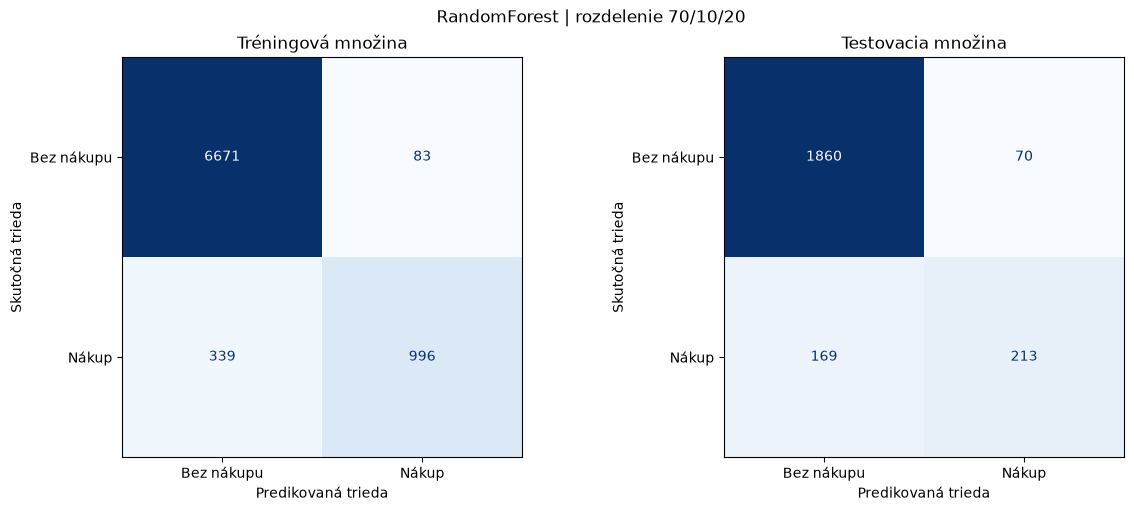

              precision    recall  f1-score   support

  Bez nákupu       0.92      0.96      0.94      1930
       Nákup       0.75      0.56      0.64       382

    accuracy                           0.90      2312
   macro avg       0.83      0.76      0.79      2312
weighted avg       0.89      0.90      0.89      2312



In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, dataset, title in [
    (axes[0], "train", "Tréningová množina"),
    (axes[1], "test", "Testovacia množina"),
]:
    ConfusionMatrixDisplay.from_estimator(
        best_model,
        best_split[f"X_{dataset}"], best_split[f"y_{dataset}"],
        labels=[0, 1], display_labels=["Bez nákupu", "Nákup"],
        cmap="Blues", values_format="d", colorbar=False, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predikovaná trieda")
    ax.set_ylabel("Skutočná trieda")

fig.suptitle(f"{best_key[1]} | rozdelenie {best_key[0]}")
plt.show()

print(classification_report(
    best_split["y_test"], best_model.predict(best_split["X_test"]),
    labels=[0, 1], target_names=["Bez nákupu", "Nákup"], zero_division=0,
))

